## Curating the data

This notebook extracts the optimised grating data from the formatted .pkl files produced by the optimisation script.

### Sort the maxima found from each core

In [6]:
### IMPORTS ###
import sys
sys.path.append('../')
from copy import deepcopy
import numpy as np
import os
os.environ["OMP_NUM_THREADS"] = "1" 
os.environ["OPENBLAS_NUM_THREADS"] = "1" 
os.environ["MKL_NUM_THREADS"] = "1" 
os.environ["VECLIB_MAXIMUM_THREADS"] = "1" 
os.environ["NUMEXPR_NUM_THREADS"] = "1" 

import autolib
import fom
import opt
import parameters
from parameters import D1_ND
I0, L, m, c = parameters.Parameters()
from twobox import TwoBox


num_cores = 200  # Number of parallelized processes used for finding optimum
maxtime = 1440  # Maximum runtime (minutes) of optimisation

folder = "./Data/0.2c-band/"
runID = f"Fasymp20_fixgaussian20_50GW"

pkl_fname = folder + f'{runID}_FOM_optimisation_maxtime{maxtime}'
txt_fname = folder + f'{runID}_FOM_optimisation_maxtime{maxtime}_curated.txt'

maxima_and_maximisers_sorted, opt_gratings_sorted, _ = opt.extract_opt(pkl_fname, num_processes=num_cores, output_opt_idx=0)

Total function evaluations: 633064
Average function evaluations per core: 3165


### Write the sorted maxima to file

In [4]:
lines_to_file = ["\n------------------------------------------------------------------------------------------------------------------------------------\n"
                , f"All maxima | (local maximum, local maximiser)\n"]

with open(txt_fname, "a") as result_file:
    result_file.writelines(lines_to_file)
    
    for idx, maxima_and_maximiser in enumerate(maxima_and_maximisers_sorted):
        result_file.write(f"Max no. {idx} | {maxima_and_maximiser}\n")

    result_file.write("------------------------------------------------------------------------------------------------------------------------------------\n")

## Extract optimal grating

In [8]:
optimum_number = 0  # Choose which optimum to extract from the sorted list (0 is the "best")

_, _, opt_grating = opt.extract_opt(pkl_fname, num_processes=num_cores, output_opt_idx=optimum_number)
optimisation_RCWA_engine = opt_grating.RCWA_engine

opt_params = opt_grating.all_params
grating = TwoBox(*opt_params, wavelength=1., angle=0., Nx=opt_grating.Nx, nG=opt_grating.nG, Qabs=np.inf, RCWA_engine=opt_grating.RCWA_engine, torcwa_edge_sharpness=opt_grating.torcwa_edge_sharpness)

Total function evaluations: 633064
Average function evaluations per core: 3165


/opt/homebrew/Caskroom/miniforge/base/envs/py12/lib/python3.12/site-packages/torcwa/rcwa.py:62: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/miniforge3/conda-bld/libtorch_1760285629010/work/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  self.L = torch.as_tensor(L,dtype=self._dtype,device=self._device)


## Plot the optimal grating eigenvalues

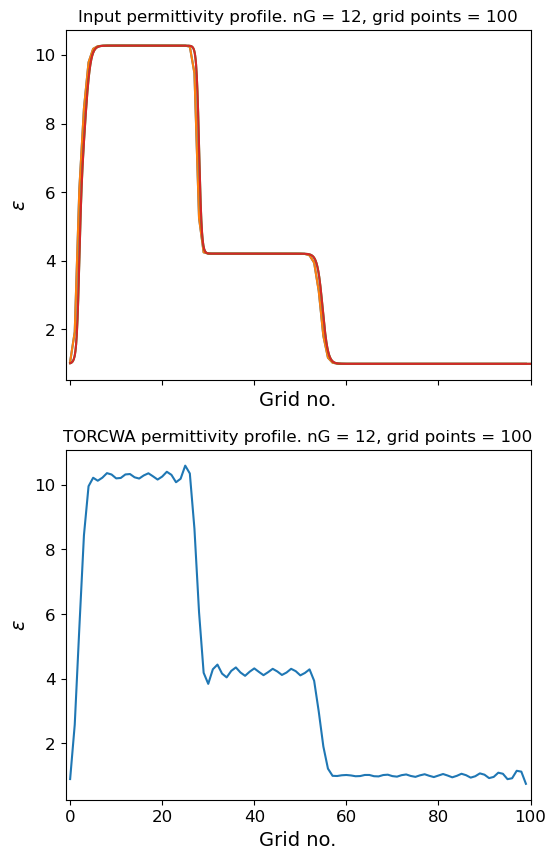

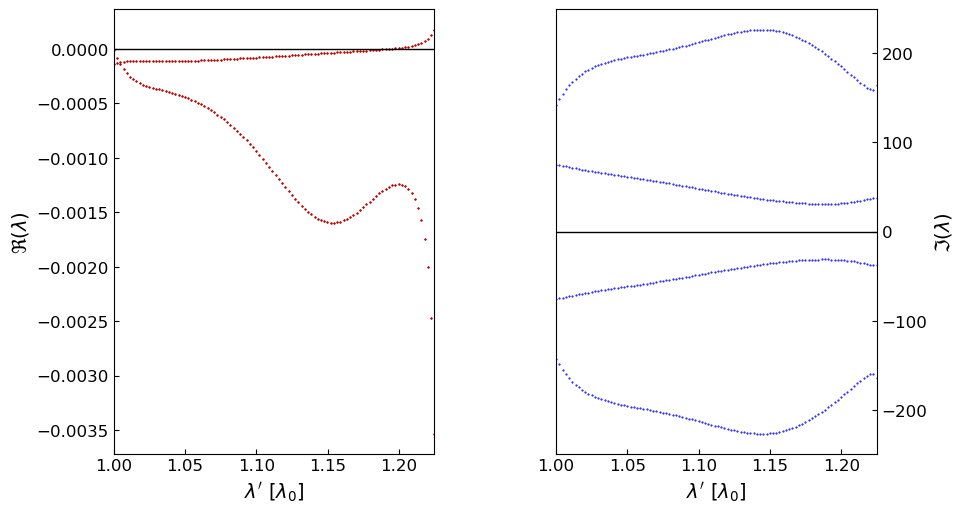

In [9]:
angle = 0.
n_plot = 100

wavelength_range = [1,1/D1_ND([0.2,0])]
_, _, p_fig, p_ax = grating.show_permittivity(show_analytic_box=True)
eig_fig, eig_ax = grating.show_Eigs(wavelength_range, I0, n_plot, False, False, 'o')

## Sensitivity

### Gradient sensitivity

In [11]:
test_params = deepcopy(opt_params)
grating = TwoBox(*test_params, wavelength=1., angle=0., Nx=opt_grating.Nx, nG=opt_grating.nG, Qabs=np.inf, RCWA_engine=opt_grating.RCWA_engine, torcwa_edge_sharpness=opt_grating.torcwa_edge_sharpness)

opt_FOM, opt_grad = fom.multifom_uniform(grating, monofom=fom.monofom_asymp, final_speed=20, goal=0.1, return_grad=True)
opt_params_np = np.array(opt_params)  # only includes the parameters that were optimised, not the fixed ones

relative_parameter_change = 0.001
normalised_grad = opt_params_np*opt_grad/opt_FOM
relative_FOM_change = normalised_grad*relative_parameter_change
percentage_FOM_change = relative_FOM_change*100

### Resonance shift

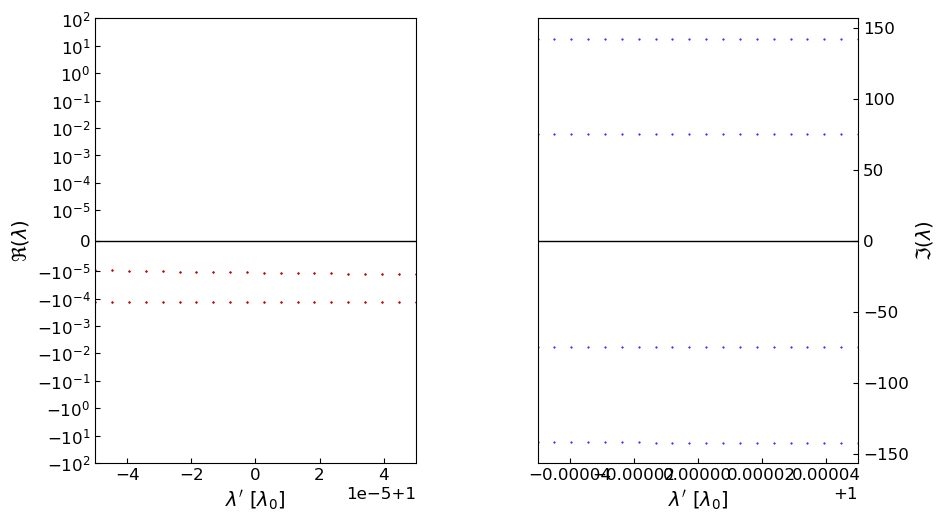

In [12]:
test_params = deepcopy(opt_params)
choose_parameter_idx = 5
original = test_params[choose_parameter_idx]
choose_parameter = "index1"
relative_change = 0e-3  # relative to original pitch
test_params[choose_parameter_idx] *= 1.+relative_change
grating = TwoBox(*test_params, wavelength=1., angle=0., Nx=opt_grating.Nx, nG=opt_grating.nG, Qabs=np.inf, RCWA_engine=opt_grating.RCWA_engine, torcwa_edge_sharpness=opt_grating.torcwa_edge_sharpness)

angle = 0.
n_plot = 20

w_range = 1e-4
wavelength_range = np.array([1-w_range/2,1+w_range/2])
eig_fig, eig_ax = grating.show_Eigs(wavelength_range, I0, n_plot, False, False, 'o')
eig_ax[0].set_yscale("symlog", linthresh=1e-5)
eig_ax[0].set_ylim(-1e2,1e2)
eig_ax[0].ticklabel_format(axis='x', style='sci', scilimits=(np.log10(w_range)-1,np.log10(w_range)-1))